## Import and Libraries

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn import metrics as met

## Extract Data From Source

In [182]:
# Load Workouts CSV to Dataframe
df_workouts = pd.read_csv('workouts.csv')

## EDA

In [183]:
# Check the first 5 rows of the dataframe
print("First 5 rows of df_exercise:")
df_workouts.head()

First 5 rows of df_exercise:


,Workout Type,Start,End,Duration,Active Energy (kJ),Resting Energy (kJ),Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),...,Step Cadence (spm),Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%),Location
0,Indoor Walk,30/04/2026 06:35,30/04/2026 06:59,00:23:07,538.376200,183.184139,5.254057,131.0,109.483214,2.039968,...,112.443579,0,0,0,NaN,0,NaN,7.750127,73,Indoor
1,Functional Strength Training,30/04/2026 06:04,30/04/2026 06:35,00:31:11,572.785416,241.291280,4.358219,151.0,99.263264,0.000000,...,8.047725,0,0,0,NaN,0,NaN,7.338853,74,Indoor
2,Outdoor Walk,29/04/2026 12:12,29/04/2026 13:09,00:56:27,1467.027552,438.588408,5.699458,146.0,107.675652,5.363411,...,109.898088,0,0,0,NaN,0,NaN,15.864819,44,Outdoor
3,Outdoor Walk,28/04/2026 12:05,28/04/2026 12:47,00:42:28,1018.672344,330.439654,5.363874,135.0,103.825171,4.051459,...,115.056386,0,0,0,NaN,0,NaN,11.998214,65,Outdoor
4,Functional Strength Training,28/04/2026 06:07,28/04/2026 06:59,00:51:47,1014.361793,400.187336,4.573515,157.0,107.747036,0.000000,...,11.948602,0,0,0,NaN,0,NaN,7.102712,82,Indoor


In [184]:
# Show all unique Workout Types
print("\nUnique Workout Types:")
print(df_workouts['Workout Type'].unique())


Unique Workout Types:
['Indoor Walk' 'Functional Strength Training' 'Outdoor Walk'
 'Indoor Cycling' 'Traditional Strength Training' 'Indoor Run'
 'Cross Training' 'High Intensity Interval Training' 'Rowing'
 'Core Training' 'Outdoor Run' 'Hiking' 'Stairs']


In [185]:
# Because we're only interested in Outdoor Walk, filter the dataframe to only include those
df_walks = df_workouts[df_workouts['Workout Type'] == 'Outdoor Walk']

In [186]:
# Drop Location column as it is not needed for analysis
df_walks = df_walks.drop(columns=['Location'])

In [187]:
# Show remaining columns information
df_walks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, 2 to 2419
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Workout Type                 1094 non-null   object 
 1   Start                        1094 non-null   object 
 2   End                          1094 non-null   object 
 3   Duration                     1094 non-null   object 
 4   Active Energy (kJ)           1094 non-null   float64
 5   Resting Energy (kJ)          1094 non-null   float64
 6   Intensity (kcal/hr·kg)       1094 non-null   float64
 7   Max. Heart Rate (count/min)  1094 non-null   float64
 8   Avg. Heart Rate (count/min)  1094 non-null   float64
 9   Distance (km)                1094 non-null   float64
 10  Max. Speed (km/hr)           1094 non-null   int64  
 11  Avg. Speed (km/hr)           1094 non-null   int64  
 12  Flights Climbed              1094 non-null   int64  
 13  Elevation Ascended (m) 

In [188]:
# Convert 'Start' to datetime, keeping only the date
df_walks['Start'] = (pd.to_datetime(df_walks['Start'], dayfirst=True).dt.normalize())

# Rename 'Start' column to 'Date' 
df_walks.rename(columns={'Start': 'Date'}, inplace=True)

# Drop 'End' column 
df_walks.drop(columns=['End'], inplace=True)

# Convert duration to minutes
df_walks['Duration'] = pd.to_timedelta(df_walks['Duration']).dt.seconds / 60

# Convert active energy to calories, and change the column name to 'Active Energy (kcal)'
df_walks["Active Energy (kcal)"] = df_walks["Active Energy (kJ)"] / 4.184

# Drop 'Active Energy (kJ)' column
df_walks.drop(columns=['Active Energy (kJ)'], inplace=True)

# Convert 'Resting Energy (kJ)' to calories, and change the column name to 'Resting Energy (kcal)'
df_walks["Resting Energy (kcal)"] = df_walks["Resting Energy (kJ)"] / 4.184

# Drop 'Resting Energy (kJ)' column
df_walks.drop(columns=['Resting Energy (kJ)'], inplace=True)    

In [189]:
# Check the sdhape to see how many rows there are:
df_walks.shape

(1094, 24)

In [190]:
# Check for duplicates
print("\nNumber of duplicate rows:", df_walks.duplicated().sum())


Number of duplicate rows: 0


In [191]:
# Check for nulls in the dataframe
print("\nNull values in df_exercise:")
print(df_walks.isnull().sum())


Null values in df_exercise:
Workout Type                      0
Date                              0
Duration                          0
Intensity (kcal/hr·kg)            0
Max. Heart Rate (count/min)       0
Avg. Heart Rate (count/min)       0
Distance (km)                     0
Max. Speed (km/hr)                0
Avg. Speed (km/hr)                0
Flights Climbed                   0
Elevation Ascended (m)            0
Elevation Descended (m)           0
Step Count                        0
Step Cadence (spm)                0
Swimming Stroke Count             0
Swim Cadence (spm)                0
Lap Length (m)                    0
Swim Stroke Style              1094
SWOLF Score                       0
Water Salinity                 1094
Temperature (degC)                0
Humidity (%)                      0
Active Energy (kcal)              0
Resting Energy (kcal)             0
dtype: int64


In [192]:
# Check columns where value is zero
print("\nZeros in df_workouts:")
print((df_walks == 0).sum())


Zeros in df_workouts:
Workout Type                      0
Date                              0
Duration                          0
Intensity (kcal/hr·kg)            3
Max. Heart Rate (count/min)       2
Avg. Heart Rate (count/min)       2
Distance (km)                     5
Max. Speed (km/hr)             1094
Avg. Speed (km/hr)             1094
Flights Climbed                1094
Elevation Ascended (m)          106
Elevation Descended (m)        1094
Step Count                        7
Step Cadence (spm)                7
Swimming Stroke Count          1094
Swim Cadence (spm)             1094
Lap Length (m)                 1094
Swim Stroke Style                 0
SWOLF Score                    1094
Water Salinity                    0
Temperature (degC)               81
Humidity (%)                     81
Active Energy (kcal)              2
Resting Energy (kcal)             2
dtype: int64


In [193]:
df_walks.describe()

,Date,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Max. Speed (km/hr),Avg. Speed (km/hr),Flights Climbed,Elevation Ascended (m),...,Swimming Stroke Count,Swim Cadence (spm),Lap Length (m),Swim Stroke Style,SWOLF Score,Water Salinity,Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
count,1094,1094.000000,1094.000000,1094.000000,1094.000000,1094.000000,1094.0,1094.0,1094.0,1094.000000,...,1094.0,1094.0,1094.0,0.0,1094.0,0.0,1094.000000,1094.000000,1094.000000,1094.000000
mean,2022-07-08 03:16:07.458866432,28.170795,4.265450,108.419561,88.469545,1.886911,0.0,0.0,0.0,17.637404,...,0.0,0.0,0.0,NaN,0.0,NaN,10.583269,69.597806,120.312460,32.737126
min,2020-04-15 00:00:00,0.116667,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,NaN,0.0,NaN,-3.000000,0.000000,0.000000,0.000000
25%,2021-03-04 06:00:00,20.862500,3.521599,92.000000,76.173659,1.091267,0.0,0.0,0.0,5.390000,...,0.0,0.0,0.0,NaN,0.0,NaN,6.000000,59.000000,70.978905,1.799639
50%,2021-08-22 12:00:00,25.166667,3.989704,106.000000,84.491228,1.322641,0.0,0.0,0.0,8.445000,...,0.0,0.0,0.0,NaN,0.0,NaN,10.604623,77.000000,89.330589,31.779271
75%,2023-07-21 06:00:00,32.020833,5.051221,122.000000,101.566066,2.263907,0.0,0.0,0.0,16.587500,...,0.0,0.0,0.0,NaN,0.0,NaN,15.000000,87.000000,135.095153,45.582712
max,2026-04-29 00:00:00,262.833333,8.514424,192.000000,172.459312,19.138312,0.0,0.0,0.0,463.890000,...,0.0,0.0,0.0,NaN,0.0,NaN,31.550000,99.000000,1481.703601,442.852509
std,NaN,16.832362,0.996448,20.600287,15.696836,1.616172,0.0,0.0,0.0,26.459152,...,0.0,0.0,0.0,NaN,0.0,NaN,6.750652,24.934517,105.197022,34.525582


In [194]:
# Show rows where active energy is zero
print("\nRows where Active Energy is zero:")
print(df_walks[df_walks['Active Energy (kcal)'] == 0])


Rows where Active Energy is zero:
      Workout Type       Date  Duration  Intensity (kcal/hr·kg)  \
1968  Outdoor Walk 2021-03-06  0.183333                     0.0   
2364  Outdoor Walk 2020-05-31  0.116667                     0.0   

      Max. Heart Rate (count/min)  Avg. Heart Rate (count/min)  Distance (km)  \
1968                         63.0                         62.0            0.0   
2364                          0.0                          0.0            0.0   

      Max. Speed (km/hr)  Avg. Speed (km/hr)  Flights Climbed  ...  \
1968                   0                   0                0  ...   
2364                   0                   0                0  ...   

      Swimming Stroke Count  Swim Cadence (spm)  Lap Length (m)  \
1968                      0                   0               0   
2364                      0                   0               0   

      Swim Stroke Style  SWOLF Score  Water Salinity  Temperature (degC)  \
1968                NaN       

In [195]:
# As these are short in duration, we can drop them as they are likely not actual walks
df_walks = df_walks[df_walks['Active Energy (kcal)'] > 0]

In [196]:
# Drop columns where all values are zero
df_walks = df_walks.loc[:, (df_walks != 0).any(axis=0)]

In [197]:
# Drop columns where all values are nulls
df_walks = df_walks.dropna(axis=1, how='all')

In [198]:
# Check columns where value is zero
print("\nZeros in df_walks:")
print((df_walks == 0).sum())


Zeros in df_walks:
Workout Type                     0
Date                             0
Duration                         0
Intensity (kcal/hr·kg)           1
Max. Heart Rate (count/min)      1
Avg. Heart Rate (count/min)      1
Distance (km)                    3
Elevation Ascended (m)         104
Step Count                       5
Step Cadence (spm)               5
Temperature (degC)              79
Humidity (%)                    79
Active Energy (kcal)             0
Resting Energy (kcal)            2
dtype: int64


In [199]:
# We can drop any rows where 'Resting Energy (kJ)', 'Intensity', 'Maximum Heart Rate (bpm)', 'Average Heart Rate (bpm)', Distance, Steps, Steps Cadence is zero as these are small in number
columns = ['Resting Energy (kcal)', 'Intensity (kcal/hr·kg)', 'Max. Heart Rate (count/min)', 'Avg. Heart Rate (count/min)', 'Distance (km)', 'Step Count', 'Step Cadence (spm)']

for col in columns:
    df_walks = df_walks[df_walks[col] > 0]

In [200]:
# Check columns where value is zero
print("\nZeros in df_workouts:")
print((df_walks == 0).sum())


Zeros in df_workouts:
Workout Type                     0
Date                             0
Duration                         0
Intensity (kcal/hr·kg)           0
Max. Heart Rate (count/min)      0
Avg. Heart Rate (count/min)      0
Distance (km)                    0
Elevation Ascended (m)         100
Step Count                       0
Step Cadence (spm)               0
Temperature (degC)              78
Humidity (%)                    78
Active Energy (kcal)             0
Resting Energy (kcal)            0
dtype: int64


In [201]:
# Check the rows where temperature and humidity are zero to see if they are valid
print("\nRows where Temperature and Humidity are zero:")
df_walks[(df_walks['Temperature (degC)'] == 0) & (df_walks['Humidity (%)'] == 0)]



Rows where Temperature and Humidity are zero:


,Workout Type,Date,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Elevation Ascended (m),Step Count,Step Cadence (spm),Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
54,Outdoor Walk,2026-03-31,34.916667,6.143492,127.0,116.144764,3.677973,40.11,3153.384163,90.275456,0.0,0,238.359751,64.369759
55,Outdoor Walk,2026-03-31,38.116667,5.568955,115.0,101.612429,4.021334,18.58,3567.267727,93.576314,0.0,0,229.441355,71.677239
57,Outdoor Walk,2026-03-30,55.933333,6.210335,143.0,108.369443,5.810612,92.01,6031.784949,107.829151,0.0,0,388.177033,103.028662
68,Outdoor Walk,2026-03-23,30.900000,5.807927,108.0,94.291667,3.161222,39.69,3016.000000,97.601821,0.0,0,196.265556,56.996825
72,Outdoor Walk,2026-03-20,45.016667,5.733110,130.0,110.519258,4.494460,53.63,4713.000000,104.675394,0.0,0,282.021716,84.387524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,Outdoor Walk,2021-02-21,38.450000,5.579394,155.0,111.995664,3.666839,39.93,4525.000000,117.639500,0.0,0,218.130274,57.359181
2018,Outdoor Walk,2021-02-14,39.233333,4.928466,117.0,90.016449,2.915910,48.12,4119.377377,104.956811,0.0,0,189.151000,69.031779
2101,Outdoor Walk,2021-01-03,45.383333,4.682575,117.0,94.316140,2.923026,71.56,4393.000000,96.790175,0.0,0,204.370910,70.532244
2131,Outdoor Walk,2020-12-08,12.966667,3.739460,87.0,74.754438,0.544092,0.00,801.405306,61.735679,0.0,0,43.057000,22.390274


In [202]:
# drop rows where temperature and humidity are zero as these are likely invalid
df_walks = df_walks[~((df_walks['Temperature (degC)'] == 0) & (df_walks['Humidity (%)'] == 0))]

In [203]:
# Check columns where value is zero
print("\nZeros in df_workouts:")
print((df_walks == 0).sum())


Zeros in df_workouts:
Workout Type                    0
Date                            0
Duration                        0
Intensity (kcal/hr·kg)          0
Max. Heart Rate (count/min)     0
Avg. Heart Rate (count/min)     0
Distance (km)                   0
Elevation Ascended (m)         81
Step Count                      0
Step Cadence (spm)              0
Temperature (degC)              0
Humidity (%)                    0
Active Energy (kcal)            0
Resting Energy (kcal)           0
dtype: int64


In [204]:
df_walks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1006 entries, 2 to 2419
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Workout Type                 1006 non-null   object        
 1   Date                         1006 non-null   datetime64[ns]
 2   Duration                     1006 non-null   float64       
 3   Intensity (kcal/hr·kg)       1006 non-null   float64       
 4   Max. Heart Rate (count/min)  1006 non-null   float64       
 5   Avg. Heart Rate (count/min)  1006 non-null   float64       
 6   Distance (km)                1006 non-null   float64       
 7   Elevation Ascended (m)       1006 non-null   float64       
 8   Step Count                   1006 non-null   float64       
 9   Step Cadence (spm)           1006 non-null   float64       
 10  Temperature (degC)           1006 non-null   float64       
 11  Humidity (%)                 1006 non-null   int

# DISTRIBUTIONS/OUTLIERS

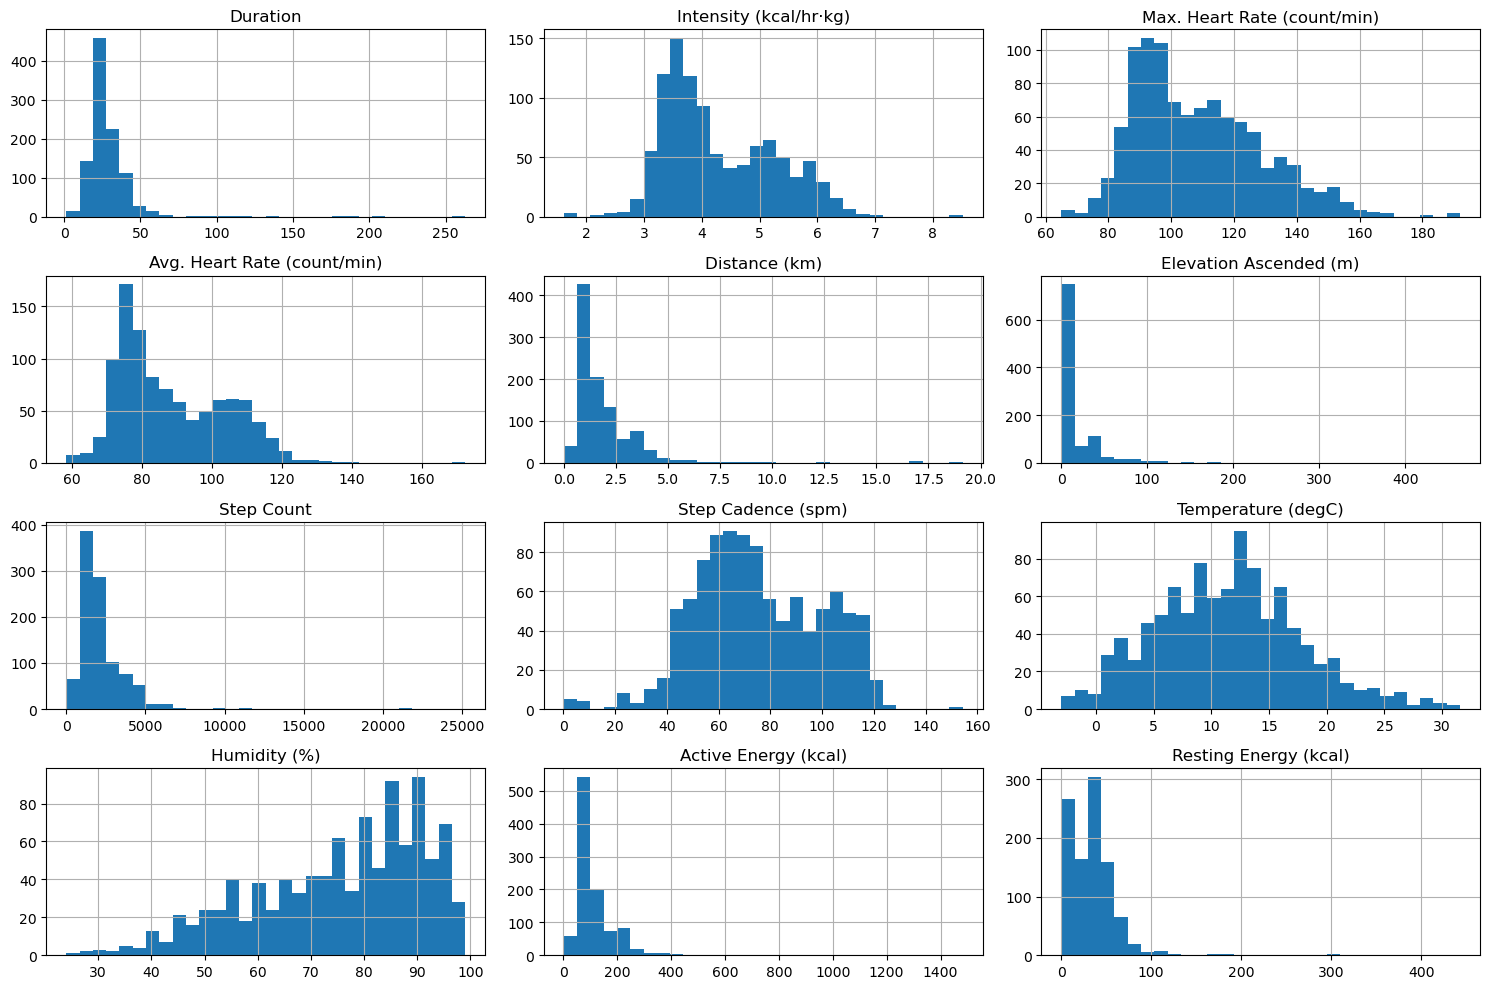

In [205]:
# Show distributions for all numeric columns
# Select numeric columns
numeric_cols = df_walks.select_dtypes(include='number').columns

# Plot histograms
df_walks[numeric_cols].hist(figsize=(15, 10), bins=30)

plt.tight_layout()
plt.show()

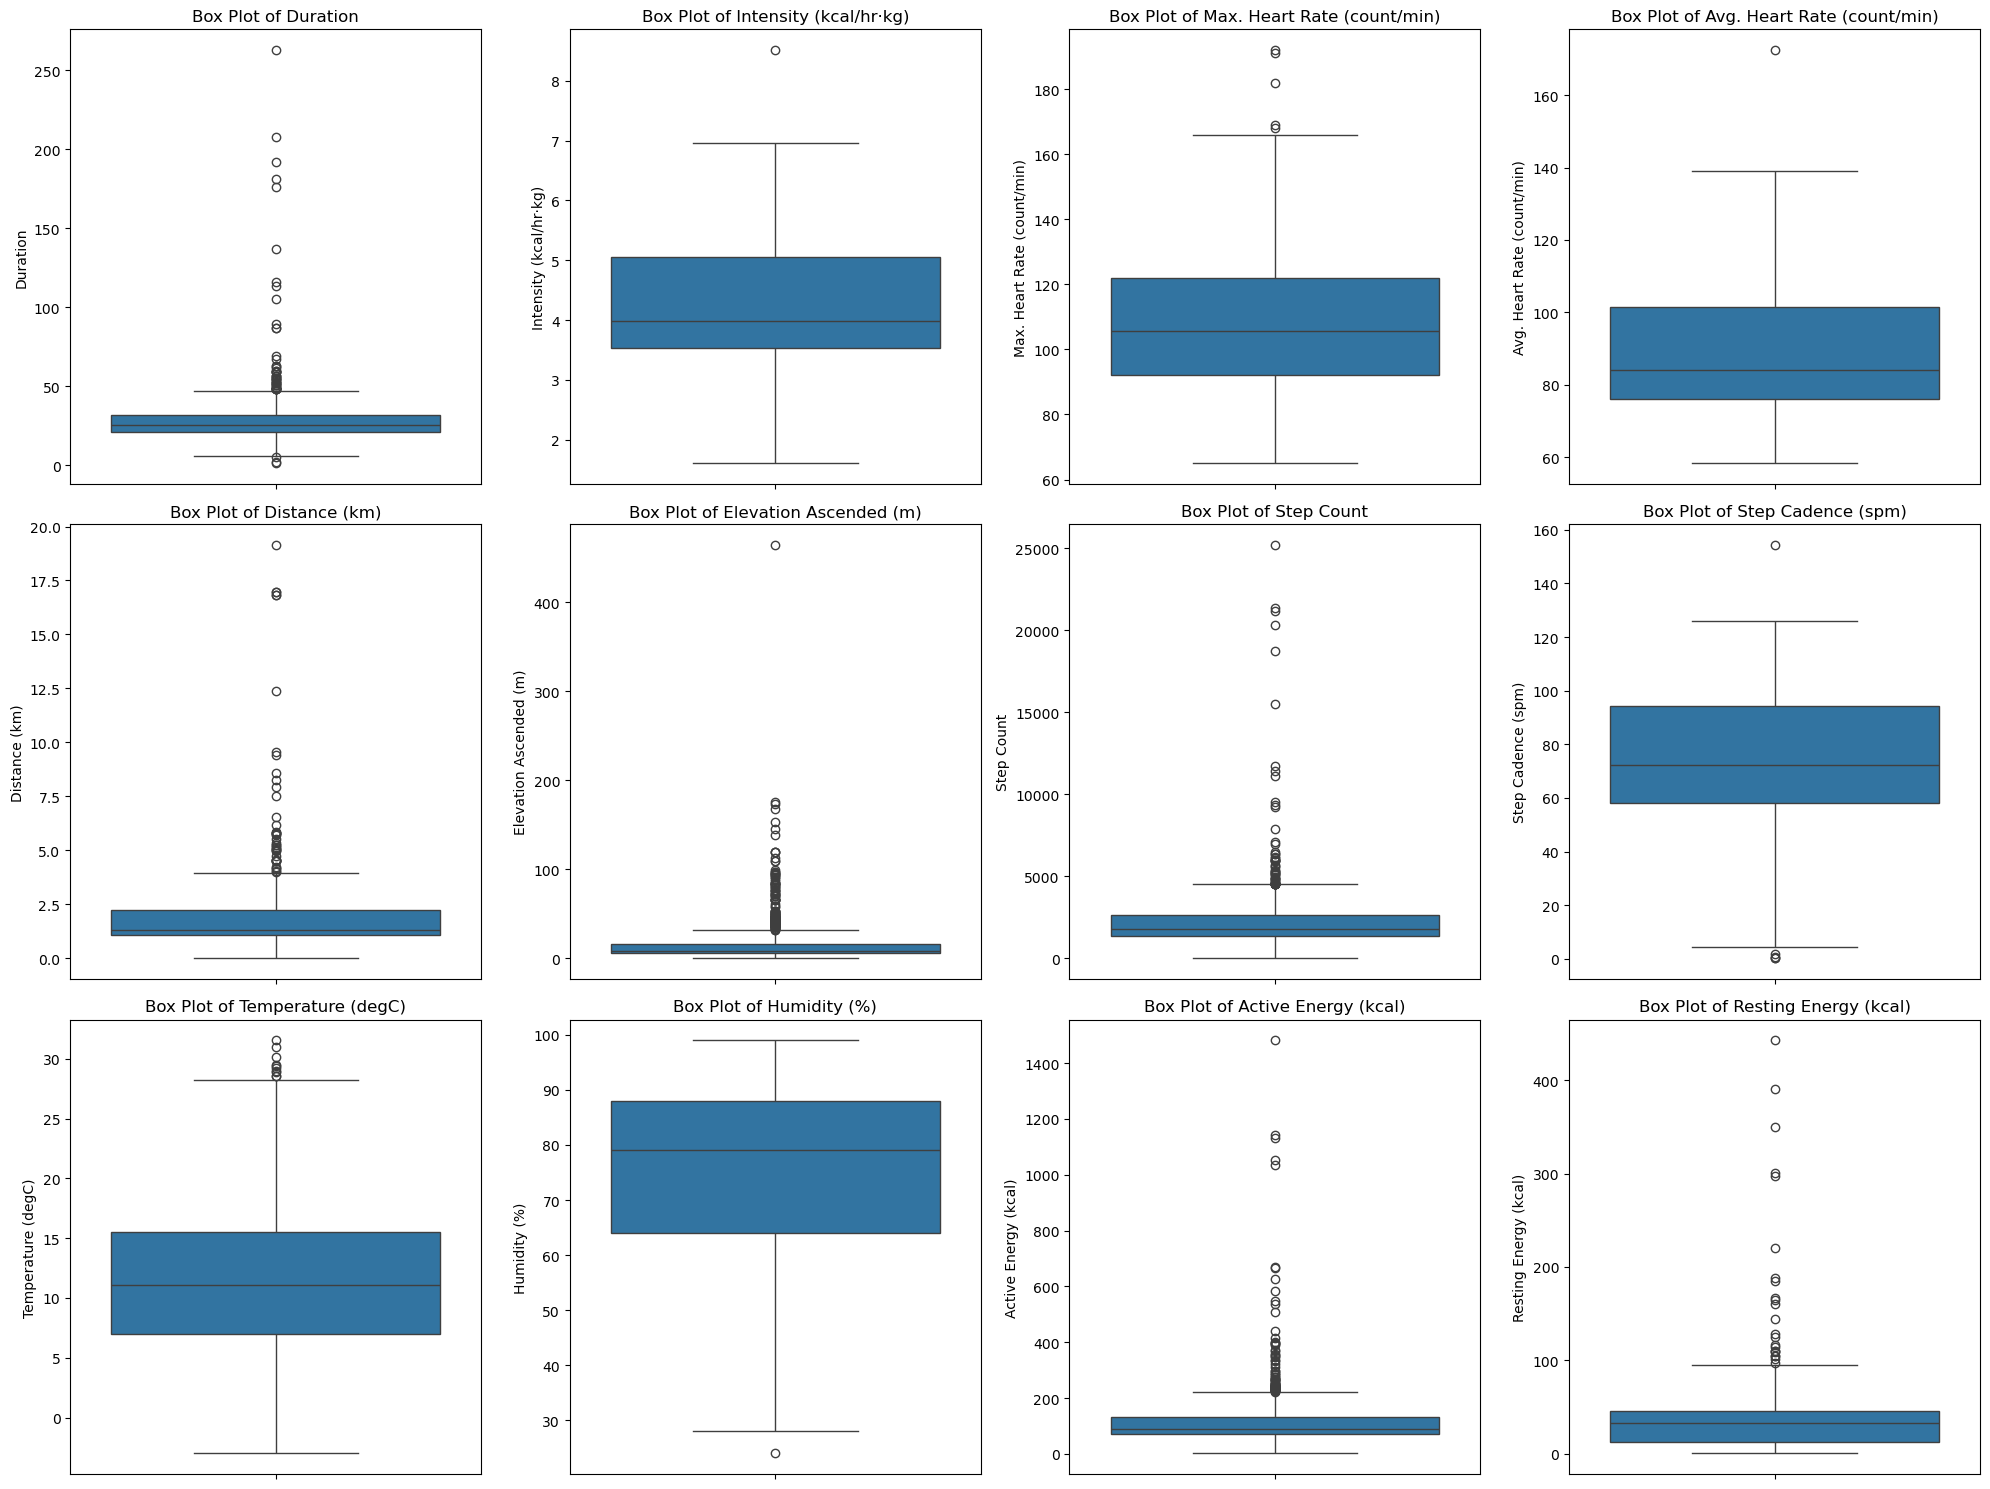

In [206]:
# Show box plots for all numeric columns to check for outliers

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_walks, y=col, ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

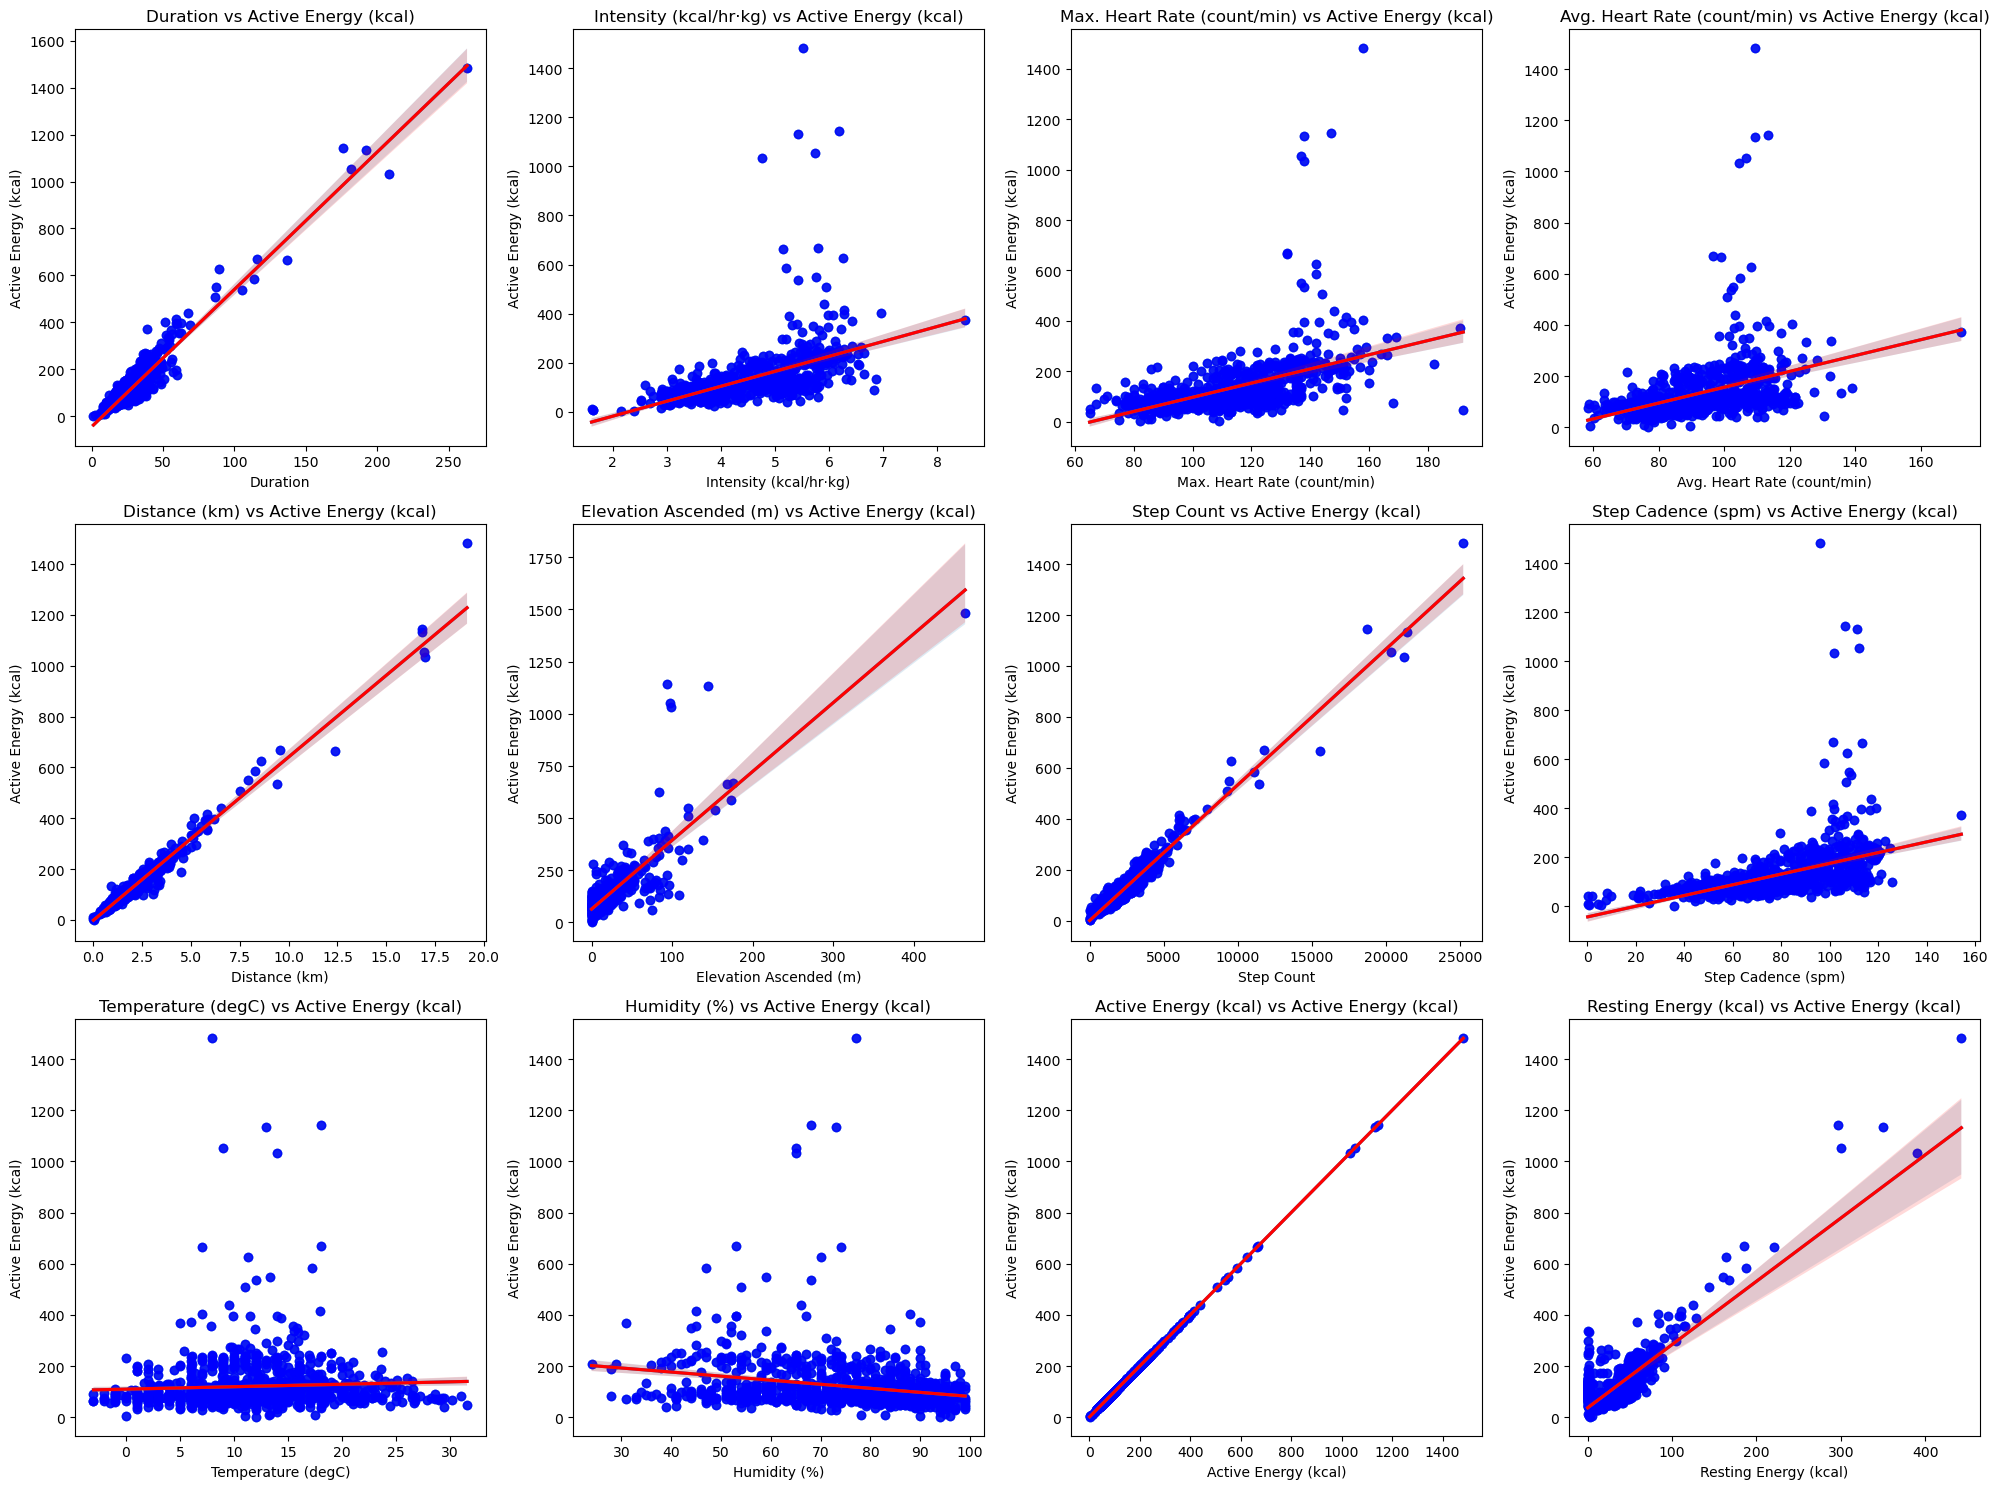

In [207]:
# Scatterplots to show the relationship between numerical features and the target variable, 

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.regplot(x=col, y='Active Energy (kcal)', data=df_walks, ax=axes[i])
    sns.regplot(x=col, y='Active Energy (kcal)', data=df_walks, ax=axes[i], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
    axes[i].set_title(f'{col} vs Active Energy (kcal)')
plt.tight_layout()
plt.show()
    



## TRAIN / TEST SPLIT

In [208]:
# train test split
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_walks, test_size=0.2, random_state=44)

In [209]:
print(df_walks.shape)
print(df_train.shape)
print(df_test.shape)


(1006, 14)
(804, 14)
(202, 14)


## CORRELATIONS IN TRAINING DATA

In [210]:
# look at training data
df_train.head()

,Workout Type,Date,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Elevation Ascended (m),Step Count,Step Cadence (spm),Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
198,Outdoor Walk,2025-12-11,21.766667,5.001283,127.0,117.298867,2.062988,2.00,2468.622805,113.341411,7.353374,89,116.412000,0.501722
1519,Outdoor Walk,2021-10-16,19.783333,3.547136,99.0,86.023365,1.000142,5.47,1065.152747,53.839870,7.000000,96,60.550000,25.751907
266,Outdoor Walk,2025-09-18,29.083333,5.017102,140.0,107.001901,2.003917,27.19,2017.000000,69.324874,25.986835,73,152.946257,1.719279
812,Outdoor Walk,2023-10-02,37.716667,5.967509,138.0,104.537070,3.520056,33.42,3906.621255,103.554262,14.610000,83,245.317566,23.908942
1500,Outdoor Walk,2021-11-13,21.600000,3.650363,91.0,78.297418,1.215668,4.89,1793.216079,82.998452,9.000000,90,66.939011,28.312897


In [211]:
# Check the correlations
df_train.corr(numeric_only = True) 


,Duration,Intensity (kcal/hr·kg),Max. Heart Rate (count/min),Avg. Heart Rate (count/min),Distance (km),Elevation Ascended (m),Step Count,Step Cadence (spm),Temperature (degC),Humidity (%),Active Energy (kcal),Resting Energy (kcal)
Duration,1.000000,0.288109,0.362319,0.225857,0.923566,0.793955,0.952746,0.306603,-0.002671,-0.122799,0.944080,0.893292
Intensity (kcal/hr·kg),0.288109,1.000000,0.710619,0.803638,0.576151,0.478772,0.490161,0.773339,0.160809,-0.363643,0.544540,0.180314
Max. Heart Rate (count/min),0.362319,0.710619,1.000000,0.839056,0.545448,0.511608,0.489769,0.594823,0.179057,-0.324521,0.530556,0.217771
Avg. Heart Rate (count/min),0.225857,0.803638,0.839056,1.000000,0.484130,0.364126,0.403575,0.660370,0.205405,-0.340272,0.446571,0.049403
Distance (km),0.923566,0.576151,0.545448,0.484130,1.000000,0.801382,0.979867,0.539180,0.071699,-0.247007,0.985426,0.794886
Elevation Ascended (m),0.793955,0.478772,0.511608,0.364126,0.801382,1.000000,0.809070,0.398074,0.005474,-0.195000,0.837951,0.715227
Step Count,0.952746,0.490161,0.489769,0.403575,0.979867,0.809070,1.000000,0.541366,0.040144,-0.202386,0.978330,0.833332
Step Cadence (spm),0.306603,0.773339,0.594823,0.660370,0.539180,0.398074,0.541366,1.000000,0.143609,-0.324225,0.483674,0.182146
Temperature (degC),-0.002671,0.160809,0.179057,0.205405,0.071699,0.005474,0.040144,0.143609,1.000000,-0.487953,0.043076,-0.148716
Humidity (%),-0.122799,-0.363643,-0.324521,-0.340272,-0.247007,-0.195000,-0.202386,-0.324225,-0.487953,1.000000,-0.210655,-0.029590


## FEATURE SELECTION

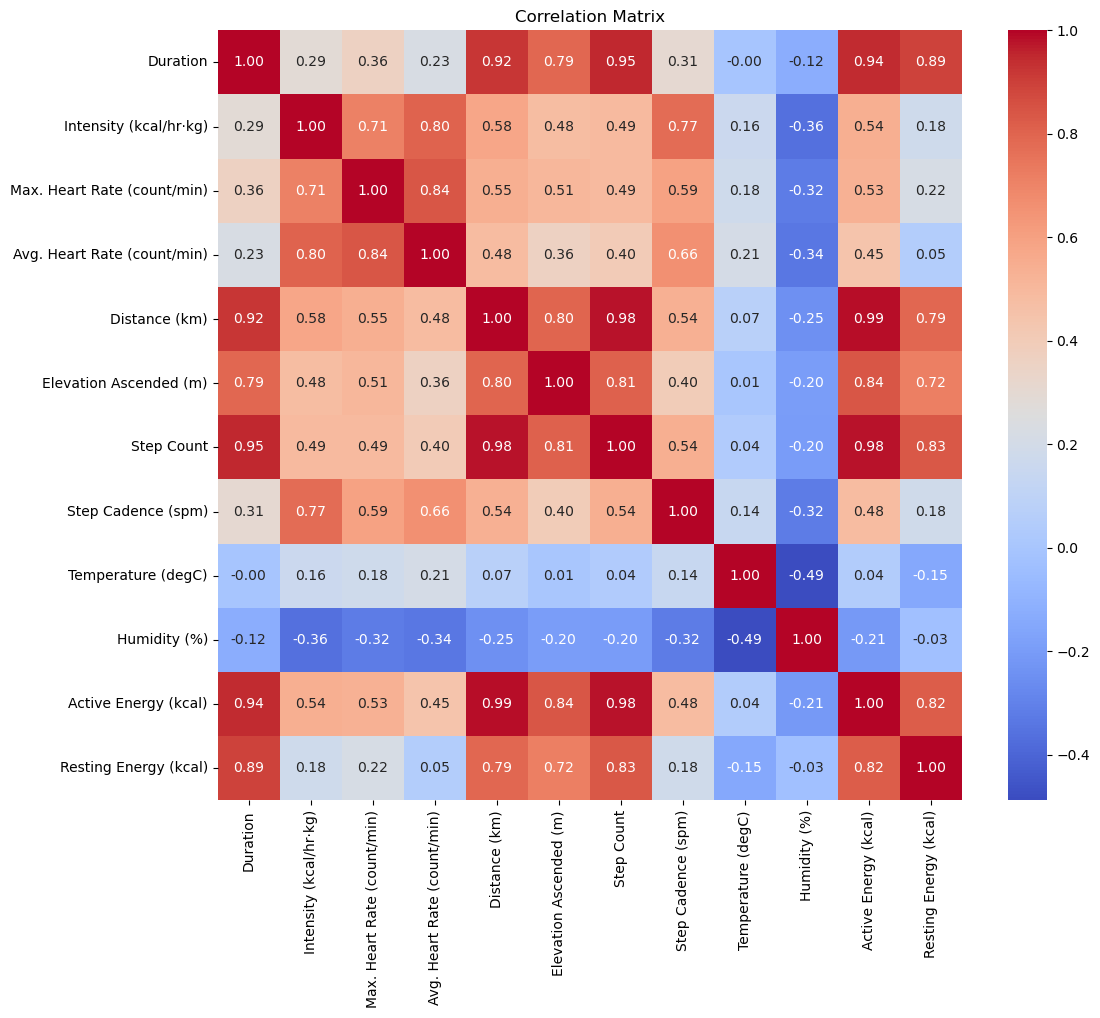

In [212]:
# Check for mulitcollinearity between variables using correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.corr(numeric_only = True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [213]:
# Max Heart rate and Avg Heart Rate are highly correlated, so we can drop one of them to avoid multicollinearity issues. 
# We will drop Max Heart Rate as Avg Heart Rate is likely more representative of the overall walk.
df_train.drop('Max. Heart Rate (count/min)', axis=1, inplace=True)
df_test.drop('Max. Heart Rate (count/min)', axis=1, inplace=True)

# Drop Duration to avoid multicollinearity issues with Distance
df_train.drop(['Duration'], axis=1, inplace=True)
df_test.drop(['Duration'], axis=1, inplace=True)

# Drop Step Count as it is highly correlated with Distance, Duration and Step Cadence
df_train.drop('Step Count', axis=1, inplace=True)
df_test.drop('Step Count', axis=1, inplace=True)

# Drop intensity as it is highly correlated with Avg Heart Rate and Step Cadcne, plus is is calulated using weight which may not be accuaret
df_train.drop('Intensity (kcal/hr·kg)', axis=1, inplace=True)
df_test.drop('Intensity (kcal/hr·kg)', axis=1, inplace=True)

# Temp, Humidity and Resting Energy have less effect on Active Energy, so we can drop them as well to simplify the model and avoid multicollinearity issues
df_train.drop(['Temperature (degC)', 'Humidity (%)', 'Resting Energy (kcal)'], axis=1, inplace=True)
df_test.drop(['Temperature (degC)', 'Humidity (%)', 'Resting Energy (kcal)'], axis=1, inplace=True)

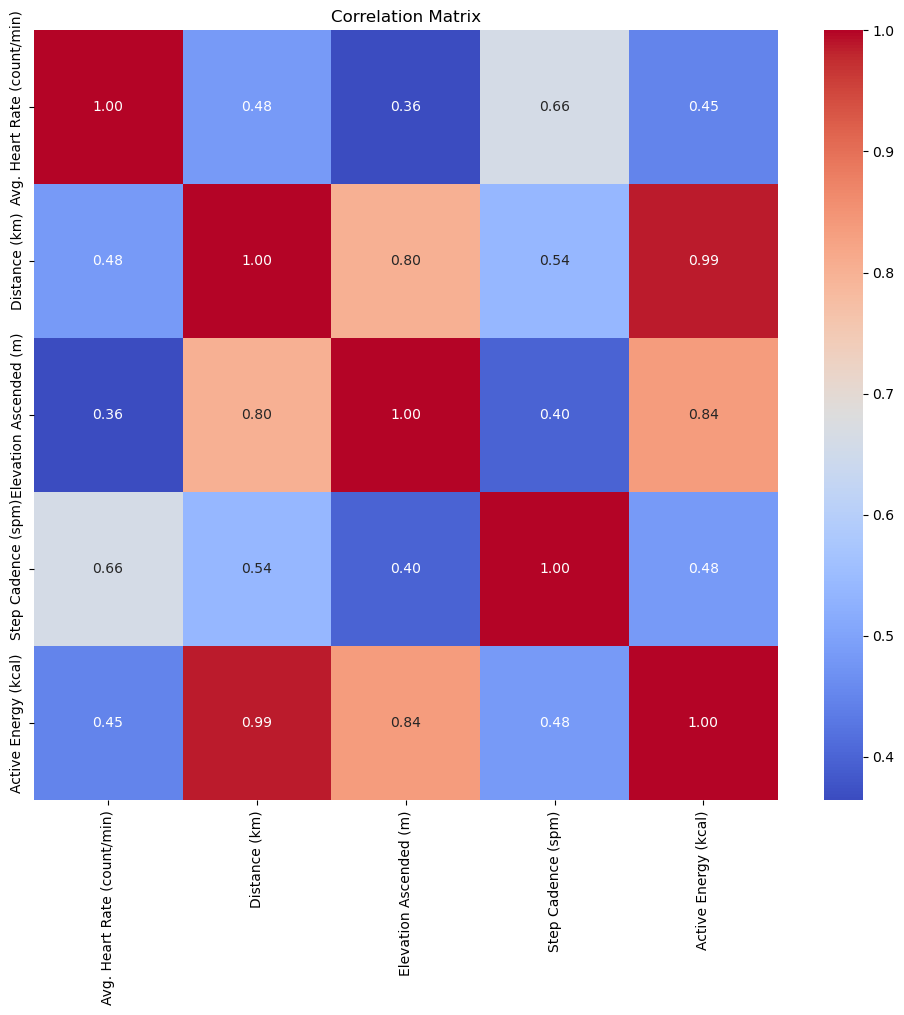

In [214]:
# Check for mulitcollinearity between variables using correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.corr(numeric_only = True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [215]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 804 entries, 198 to 2035
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Workout Type                 804 non-null    object        
 1   Date                         804 non-null    datetime64[ns]
 2   Avg. Heart Rate (count/min)  804 non-null    float64       
 3   Distance (km)                804 non-null    float64       
 4   Elevation Ascended (m)       804 non-null    float64       
 5   Step Cadence (spm)           804 non-null    float64       
 6   Active Energy (kcal)         804 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 50.2+ KB


## BUILD LINEAR REGRESSION MODEL

In [216]:
# Separate target (y) from the input variables X
y_train = df_train['Active Energy (kcal)']
y_test = df_test['Active Energy (kcal)']

# We can drop Workout Type and Date as they are not needed for the model, and Active Energy (kcal) as it is our target variable
X_train = df_train.drop(['Active Energy (kcal)', 'Workout Type', 'Date'], axis=1)
X_test = df_test.drop(['Active Energy (kcal)', 'Workout Type', 'Date'], axis=1)



In [217]:
X_test

,Avg. Heart Rate (count/min),Distance (km),Elevation Ascended (m),Step Cadence (spm)
322,98.708333,1.335851,0.00,82.627131
37,107.041667,2.460030,28.13,77.577023
129,118.427904,2.169726,15.00,121.200032
967,71.708333,2.023437,37.07,71.015112
820,85.346357,1.617164,14.45,79.870529
...,...,...,...,...
2321,74.806852,1.167836,7.29,50.136055
1611,82.000000,1.114469,7.07,71.436428
1808,96.406418,2.078352,4.15,102.522380
197,116.206379,2.034369,7.00,103.772276


In [218]:
# Inspect the shapes of test and train sets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(804, 4)
(202, 4)
(804,)
(202,)


In [219]:
# Train Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [220]:
# Show coefficients and intercept for the fitted linear model
coef = model.coef_
intercept = model.intercept_
features = X_train.columns

coef_df = pd.DataFrame({'feature': features, 'coefficient': coef})
print("Intercept:", intercept)
print(coef_df.reset_index(drop=True))

Intercept: 22.27067129762591
                       feature  coefficient
0  Avg. Heart Rate (count/min)    -0.041937
1                Distance (km)    60.026193
2       Elevation Ascended (m)     0.524102
3           Step Cadence (spm)    -0.273993


In [221]:
# Fucntion to create mape
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [222]:


# Predict y_pred based on X_test
y_pred = model.predict(X_test)

# R2 score - how well the model fits the data
r2_score = met.r2_score(y_test, y_pred)

# MAE - mean absolute error
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2_score)
print("MAE:", mae)

R2: 0.9587215155138947
MAE: 10.018220192134805


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


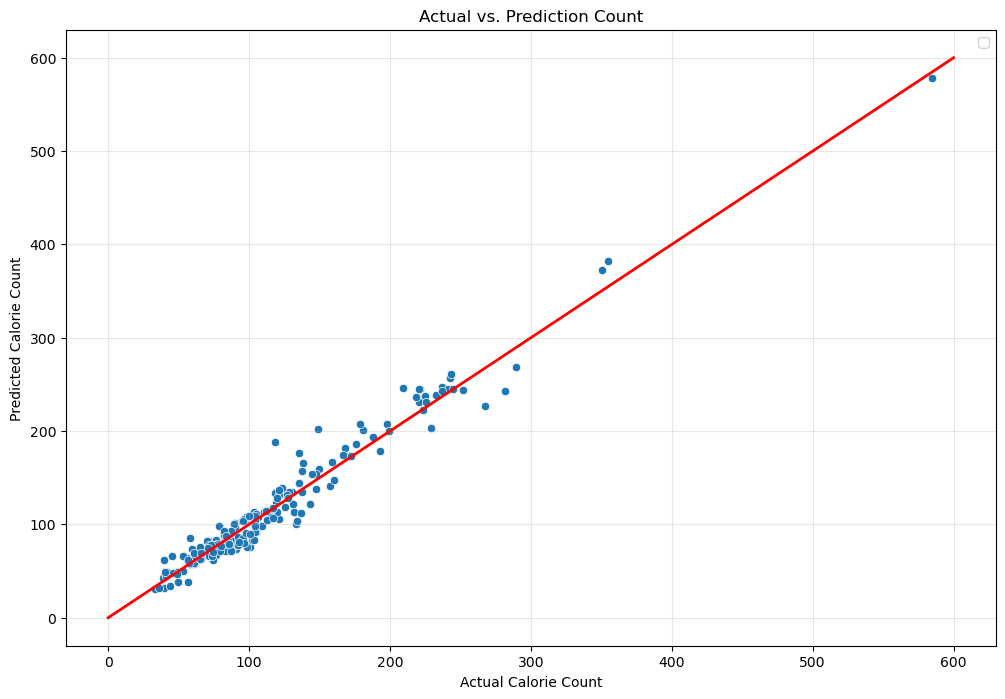

In [223]:
plt.figure(figsize=(12, 8))

plot = sns.scatterplot(x=y_test, y=y_pred).set(xlabel='Actual Calorie Count', ylabel='Predicted Calorie Count')

plt.plot([0, 600], [0, 600], color='red', lw=2)
plt.title(f'Actual vs. Prediction Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()